## WHACS Strom Classification & Analysis

### Import libraries and Load the Dataset

In [4]:
#import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from pathlib import Path
import zipfile

In [ ]:
import zipfile
import pandas as pd
#file path to the zip file
file_path = "/Users/blesso/WHACS/analysis/finalmerged.csv.zip"

# Open the ZIP and specifically pick the CSV file inside it
with zipfile.ZipFile(file_path, 'r') as z:
    # We open 'merged_all_vars_with_tp.csv' directly
    with z.open('merged_all_vars_with_tp.csv') as f:
        df = pd.read_csv(f)

#  Verify the column names 
print("Columns in this file:", df.columns.tolist())

# View the data
df.head()

Columns in this file: ['time', 'latitude', 'longitude', 'dir', 'fp', 'hs', 'cge', 'tp']


,time,latitude,longitude,dir,fp,hs,cge,tp
0,1999-01-01 00:00:00,-44.5,171.5000,102.2,0.082,0.510,1.3,12.195122
1,1999-01-01 00:00:00,-44.5,171.5625,103.4,0.083,0.538,1.4,12.048193
2,1999-01-01 00:00:00,-44.5,171.6250,105.2,0.083,0.568,1.5,12.048193
3,1999-01-01 00:00:00,-44.5,171.6875,107.7,0.083,0.600,1.7,12.048193
4,1999-01-01 00:00:00,-44.5,171.7500,111.1,0.083,0.632,1.9,12.048193


: 

The cleaned WHACS dataset contains hourly wave information for the Canterbury region, including time, location (latitude and longitude), wave direction (dir), peak frequency (fp), significant wave height (hs), wave energy flux (cge), and peak wave period (tp). The preview confirms that the dataset is correctly structured, with consistent timestamps and physically realistic wave values at multiple grid points. 

### Variable Overview and Renaming

In [5]:
df["time"] = pd.to_datetime(df["time"])


In [1]:
import zipfile
import pandas as pd

zip_path = "/Users/blesso/WHACS/analysis/finalmerged.csv.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    with z.open("merged_all_vars_with_tp.csv") as f:
        whacs_hourly = pd.read_csv(f)

whacs_hourly.head()


,time,latitude,longitude,dir,fp,hs,cge,tp
0,1999-01-01 00:00:00,-44.5,171.5000,102.2,0.082,0.510,1.3,12.195122
1,1999-01-01 00:00:00,-44.5,171.5625,103.4,0.083,0.538,1.4,12.048193
2,1999-01-01 00:00:00,-44.5,171.6250,105.2,0.083,0.568,1.5,12.048193
3,1999-01-01 00:00:00,-44.5,171.6875,107.7,0.083,0.600,1.7,12.048193
4,1999-01-01 00:00:00,-44.5,171.7500,111.1,0.083,0.632,1.9,12.048193


In [2]:
whacs_hourly["time"] = pd.to_datetime(whacs_hourly["time"])


Define storm condition (same as ECAN & Hindcast)

In [13]:
HS_THRESHOLD = 2.5
whacs_hourly["is_storm"] = whacs_hourly["hs"] >= HS_THRESHOLD


Create monthly timestamp

In [14]:
#Calculate WHACS storm hours per month
whacs_storm_hours = (
    whacs_hourly[whacs_hourly["is_storm"]]
    .groupby("month")
    .agg(whacs_storm_hours=("is_storm", "count"))
    .reset_index()
)


In [15]:
whacs_storm_hours.head(10)


,month,whacs_storm_hours
0,1999-01-01,61613
1,1999-02-01,63916
2,1999-03-01,107516
3,1999-04-01,123211
4,1999-05-01,144618
5,1999-06-01,137681
6,1999-07-01,292629
7,1999-08-01,198995
8,1999-09-01,145219
9,1999-10-01,129143


In [17]:
whacs_monthly_metrics = (
    whacs_hourly
    .groupby("month")
    .agg(
        whacs_storm_count=("is_storm", "size"),
        whacs_max_peak_Hs=("hs", "max"),
        whacs_mean_peak_Hs=("hs", "mean"),
        whacs_mean_dir=("dir", "mean")
    )
    .reset_index()
)

whacs_monthly_metrics.head()


,month,whacs_storm_count,whacs_max_peak_Hs,whacs_mean_peak_Hs,whacs_mean_dir
0,1999-01-01,1786339,4.266,1.557679,127.507140
1,1999-02-01,1613472,5.494,1.584581,130.778388
2,1999-03-01,1786334,6.796,1.738401,125.827223
3,1999-04-01,1728715,6.418,1.860189,155.193916
4,1999-05-01,1786339,6.926,1.834191,163.364454


In [18]:
whacs_monthly = pd.merge(
    whacs_monthly_metrics,
    whacs_storm_hours,
    on="month",
    how="left"
)

whacs_monthly.head()


,month,whacs_storm_count,whacs_max_peak_Hs,whacs_mean_peak_Hs,whacs_mean_dir,whacs_storm_hours
0,1999-01-01,1786339,4.266,1.557679,127.507140,61613
1,1999-02-01,1613472,5.494,1.584581,130.778388,63916
2,1999-03-01,1786334,6.796,1.738401,125.827223,107516
3,1999-04-01,1728715,6.418,1.860189,155.193916,123211
4,1999-05-01,1786339,6.926,1.834191,163.364454,144618


In [19]:
whacs_monthly["month_str"] = whacs_monthly["month"].dt.strftime("%Y-%d-%m")

whacs_monthly[["month", "month_str"]].head()


,month,month_str
0,1999-01-01,1999-01-01
1,1999-02-01,1999-01-02
2,1999-03-01,1999-01-03
3,1999-04-01,1999-01-04
4,1999-05-01,1999-01-05


In [24]:
whacs_monthly.to_csv(
    "master_with_strom_types_WHACS.csv",
    index=False
)

print("Saved: master_with_strom_types_WHACS.csv")


Saved: master_with_strom_types_WHACS.csv


In [21]:
whacs_monthly[["month", "whacs_storm_hours"]].head(12)


,month,whacs_storm_hours
0,1999-01-01,61613
1,1999-02-01,63916
2,1999-03-01,107516
3,1999-04-01,123211
4,1999-05-01,144618
5,1999-06-01,137681
6,1999-07-01,292629
7,1999-08-01,198995
8,1999-09-01,145219
9,1999-10-01,129143


Significant Wave Height vs Time

This plot provides context for storm detection and confirms the temporal continuity of the whacs  data.

In [6]:
df_ts = (
    df.groupby("time", as_index=False)
      .agg(
          Hs=("hs", "max"),      # regional extreme wave height
          Dp=("dir", "mean")     # mean wave direction
      )
)

df_ts.head()


,time,Hs,Dp
0,1999-01-01 00:00:00,2.338,137.601638
1,1999-01-01 01:00:00,2.484,140.751638
2,1999-01-01 02:00:00,2.588,143.370690
3,1999-01-01 03:00:00,2.676,144.862586
4,1999-01-01 04:00:00,2.750,144.993966


In [7]:
threshold = 2.5

df_ts["storm_flag"] = df_ts["Hs"] > threshold
df_ts["storm_group"] = (df_ts["storm_flag"] != df_ts["storm_flag"].shift()).cumsum()


In [8]:
storms = (
    df_ts[df_ts["storm_flag"]]
    .groupby("storm_group")
    .agg(
        start_time=("time", "min"),
        end_time=("time", "max"),
        duration_hours=("time", lambda x: (x.iloc[-1] - x.iloc[0]).total_seconds() / 3600),
        peak_Hs=("Hs", "max"),
        mean_direction=("Dp", "mean"),
    )
    .reset_index(drop=True)
)

storms.head()


,start_time,end_time,duration_hours,peak_Hs,mean_direction
0,1999-01-01 02:00:00,1999-01-02 13:00:00,35.0,2.882,158.202158
1,1999-01-07 22:00:00,1999-01-09 18:00:00,44.0,3.748,186.532960
2,1999-01-13 21:00:00,1999-01-15 09:00:00,36.0,3.286,106.935266
3,1999-01-26 07:00:00,1999-01-27 00:00:00,17.0,2.830,85.938343
4,1999-01-27 04:00:00,1999-01-27 19:00:00,15.0,2.680,149.767015


In [9]:
len(storms)


2209

In [11]:
storms.describe()


,start_time,end_time,duration_hours,peak_Hs,mean_direction
count,2209,2209,2209.000000,2209.000000,2209.000000
mean,2011-07-22 14:51:21.756451072,2011-07-24 23:20:46.717971968,56.490267,3.785894,144.426461
min,1999-01-01 02:00:00,1999-01-02 13:00:00,0.000000,2.502000,48.157953
25%,2005-03-03 02:00:00,2005-03-09 15:00:00,13.000000,2.778000,113.281551
50%,2011-08-20 23:00:00,2011-08-26 04:00:00,35.000000,3.352000,157.416621
75%,2017-11-04 05:00:00,2017-11-04 08:00:00,72.000000,4.418000,180.487874
max,2023-12-31 13:00:00,2023-12-31 23:00:00,582.000000,10.798000,236.871466
std,NaN,NaN,65.903991,1.310899,41.646342


In [15]:
storms.to_csv("WHACS_storm_metrics.csv", index=False)


Storm events were identified from the WHACS hindcast time series using a threshold-based approach. A storm was defined as any period where the significant wave height (Hs) exceeded 2.5 m. Consecutive exceedances were grouped into individual storm events, with each event characterised by its start time, end time, total duration, peak significant wave height, and mean wave direction. This approach converts the continuous hourly wave record into a discrete storm catalogue suitable for statistical analysis and comparison with observed and coastal response datasets.

### Peak strom Intensity distribution


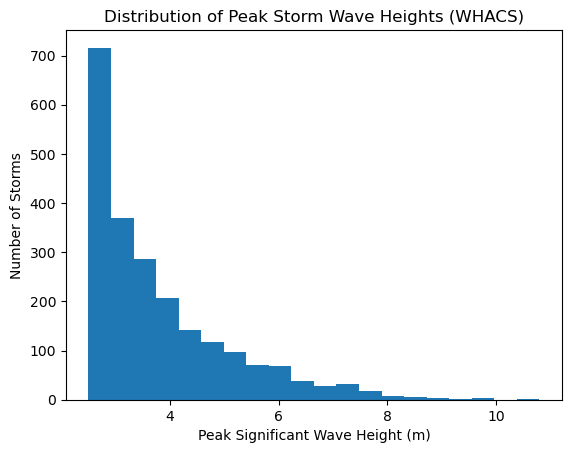

In [12]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(storms["peak_Hs"], bins=20)
plt.xlabel("Peak Significant Wave Height (m)")
plt.ylabel("Number of Storms")
plt.title("Distribution of Peak Storm Wave Heights (WHACS)")
plt.show()


The distribution of peak significant wave heights for WHACS storm events is strongly right-skewed. Most storms have moderate peak wave heights between 2.5 m and 4 m, while higher-intensity storms occur much less frequently. A small number of extreme events exceed 6 m, indicating that rare but energetic storms dominate the upper tail of the distribution and are likely to have the greatest coastal impact.

Duration VS Intensity

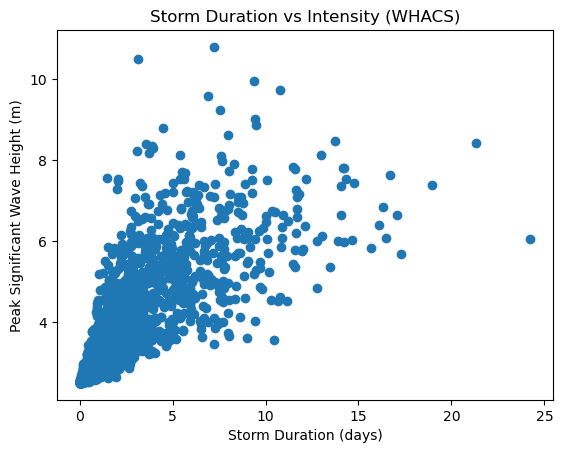

In [13]:
plt.figure()
plt.scatter(storms["duration_hours"] / 24, storms["peak_Hs"])
plt.xlabel("Storm Duration (days)")
plt.ylabel("Peak Significant Wave Height (m)")
plt.title("Storm Duration vs Intensity (WHACS)")
plt.show()


This plot shows the relationship between storm duration and peak significant wave height for WHACS storm events. Shorter storms are the most common and typically have lower peak wave heights, while longer-duration storms tend to be associated with higher intensities. Although there is considerable scatter, the overall pattern suggests that prolonged storms are more likely to produce larger waves, highlighting their greater potential for coastal impact.

Direction VS Intensity

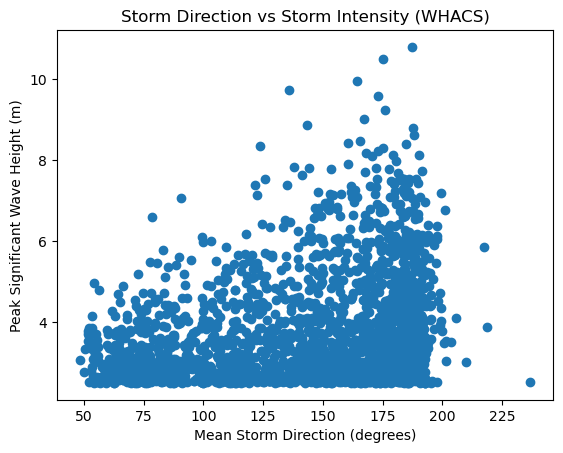

In [14]:
plt.figure()
plt.scatter(storms["mean_direction"], storms["peak_Hs"])
plt.xlabel("Mean Storm Direction (degrees)")
plt.ylabel("Peak Significant Wave Height (m)")
plt.title("Storm Direction vs Storm Intensity (WHACS)")
plt.show()


This figure shows the relationship between mean storm direction and peak significant wave height for WHACS storm events. The high density of points reflects the large number of storms and the continuous nature of wave direction. Most storms cluster between approximately 120° and 190°, indicating a dominant directional sector, while higher wave heights tend to occur within this same range. The spread in intensity suggests that storm direction influences wave height, but it is not the sole controlling factor.

### Storm Typology Using Unsupervised Clustering (WHACS)

In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd


In [2]:
storms = pd.read_csv(
    "WHACS_storm_metrics.csv",
    parse_dates=["start_time", "end_time"]
)


In [3]:
features = storms[["peak_Hs", "duration_hours", "mean_direction"]].dropna()


Standardise  the features

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)


In [5]:
#apply k-means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)


In [6]:
storms_clustered = storms.loc[features.index].copy()
storms_clustered["storm_type"] = clusters


In [12]:
storm_type_names = {
    0: "Moderate Short-Duration Storms",
    1: "Short-Lived Directional Storms",
    2: "Severe Long-Duration Storms"
}
storms_clustered["storm_type_name"] = (
    storms_clustered["storm_type"]
    .map(storm_type_names)
)
storms_clustered[["storm_type", "storm_type_name"]].head()


,storm_type,storm_type_name
0,0,Moderate Short-Duration Storms
1,0,Moderate Short-Duration Storms
2,1,Short-Lived Directional Storms
3,1,Short-Lived Directional Storms
4,0,Moderate Short-Duration Storms


In [13]:
#Examine strom types


cluster_summary = (
    storms_clustered
    .groupby("storm_type_name")
    .agg(
        storm_count=("peak_Hs", "count"),
        mean_peak_Hs=("peak_Hs", "mean"),
        mean_duration=("duration_hours", "mean"),
        mean_direction=("mean_direction", "mean")
    )
)

cluster_summary


,storm_count,mean_peak_Hs,mean_duration,mean_direction
storm_type_name,,,,
Moderate Short-Duration Storms,1088,3.316057,33.461397,170.192891
Severe Long-Duration Storms,437,5.886581,158.432494,164.707035
Short-Lived Directional Storms,684,3.191132,27.991228,90.484230


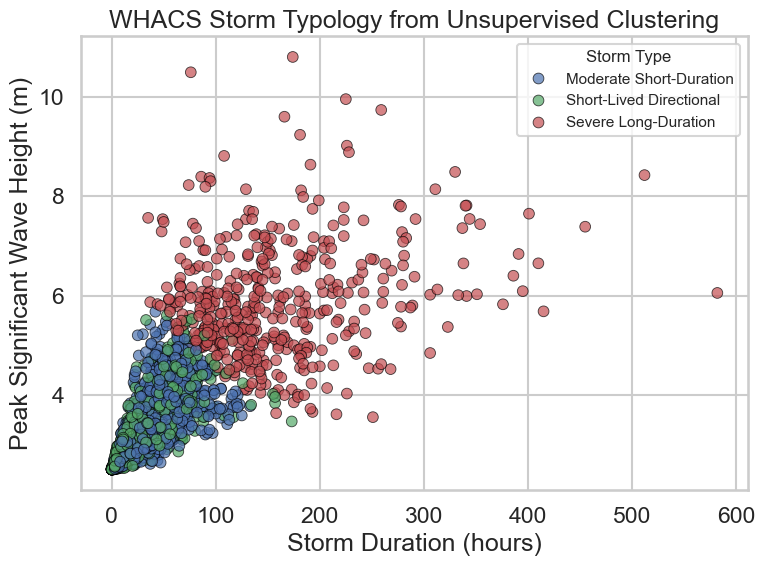

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# nicer style
sns.set_style("whitegrid")
sns.set_context("talk")

# map numeric cluster to names
storm_type_names = {
    0: "Moderate Short-Duration",
    1: "Short-Lived Directional",
    2: "Severe Long-Duration"
}

storms_clustered["storm_type_name"] = (
    storms_clustered["storm_type"]
    .map(storm_type_names)
)

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=storms_clustered,
    x="duration_hours",
    y="peak_Hs",
    hue="storm_type_name",
    palette=["#4C72B0", "#55A868", "#C44E52"],
    alpha=0.7,
    edgecolor="k",
    s=60
)

plt.xlabel("Storm Duration (hours)")
plt.ylabel("Peak Significant Wave Height (m)")
plt.title("WHACS Storm Typology from Unsupervised Clustering")

plt.legend(
    title="Storm Type",
    frameon=True,
    fontsize=11,
    title_fontsize=12
)

plt.tight_layout()
plt.show()


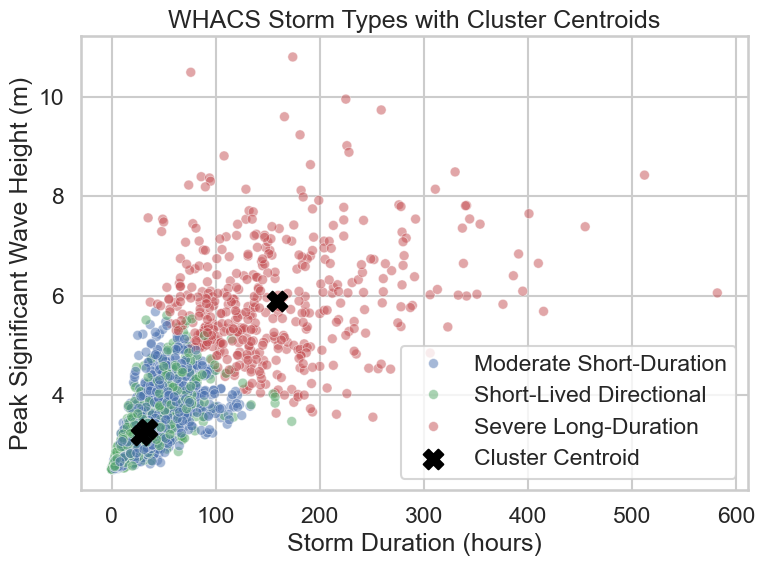

In [17]:
centroids = storms_clustered.groupby("storm_type_name")[["duration_hours", "peak_Hs"]].mean()

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=storms_clustered,
    x="duration_hours",
    y="peak_Hs",
    hue="storm_type_name",
    palette=["#4C72B0", "#55A868", "#C44E52"],
    alpha=0.5,
    s=50
)

plt.scatter(
    centroids["duration_hours"],
    centroids["peak_Hs"],
    c="black",
    s=200,
    marker="X",
    label="Cluster Centroid"
)

plt.xlabel("Storm Duration (hours)")
plt.ylabel("Peak Significant Wave Height (m)")
plt.title("WHACS Storm Types with Cluster Centroids")
plt.legend()
plt.tight_layout()
plt.show()


Storm events were classified using K-means clustering based on peak significant wave height, storm duration, and mean wave direction. Three physically distinct storm types were identified, including moderate short-duration storms, short-lived directional storms, and a smaller but more intense class of severe long-duration storms.

In [18]:
storms_clustered.to_csv(
    "WHACS_storms_with_types.csv",
    index=False
)
storms_clustered.head()


,start_time,end_time,duration_hours,peak_Hs,mean_direction,storm_type,storm_type_name
0,1999-01-01 02:00:00,1999-01-02 13:00:00,35.0,2.882,158.202158,0,Moderate Short-Duration
1,1999-01-07 22:00:00,1999-01-09 18:00:00,44.0,3.748,186.532960,0,Moderate Short-Duration
2,1999-01-13 21:00:00,1999-01-15 09:00:00,36.0,3.286,106.935266,1,Short-Lived Directional
3,1999-01-26 07:00:00,1999-01-27 00:00:00,17.0,2.830,85.938343,1,Short-Lived Directional
4,1999-01-27 04:00:00,1999-01-27 19:00:00,15.0,2.680,149.767015,0,Moderate Short-Duration


In [19]:
import pandas as pd

whacs = pd.read_csv("WHACS_storm_metrics.csv")
whacs.head()


,start_time,end_time,duration_hours,peak_Hs,mean_direction
0,1999-01-01 02:00:00,1999-01-02 13:00:00,35.0,2.882,158.202158
1,1999-01-07 22:00:00,1999-01-09 18:00:00,44.0,3.748,186.532960
2,1999-01-13 21:00:00,1999-01-15 09:00:00,36.0,3.286,106.935266
3,1999-01-26 07:00:00,1999-01-27 00:00:00,17.0,2.830,85.938343
4,1999-01-27 04:00:00,1999-01-27 19:00:00,15.0,2.680,149.767015


In [20]:
whacs["start_time"] = pd.to_datetime(whacs["start_time"])
whacs["month"] = whacs["start_time"].dt.to_period("M").dt.to_timestamp()


In [21]:
whacs[["start_time", "month"]].head()


,start_time,month
0,1999-01-01 02:00:00,1999-01-01
1,1999-01-07 22:00:00,1999-01-01
2,1999-01-13 21:00:00,1999-01-01
3,1999-01-26 07:00:00,1999-01-01
4,1999-01-27 04:00:00,1999-01-01


In [22]:
whacs_monthly = (
    whacs
    .groupby("month")
    .agg(
        whacs_storm_count=("peak_Hs", "count"),
        whacs_mean_peak_Hs=("peak_Hs", "mean"),
        whacs_max_peak_Hs=("peak_Hs", "max"),
        whacs_mean_dir=("mean_direction", "mean")
    )
    .reset_index()
)


In [23]:
whacs_monthly.head()


,month,whacs_storm_count,whacs_mean_peak_Hs,whacs_max_peak_Hs,whacs_mean_dir
0,1999-01-01,6,3.282000,4.266,137.324438
1,1999-02-01,7,3.594571,6.796,121.318580
2,1999-03-01,8,3.042000,4.102,136.744316
3,1999-04-01,5,3.674000,6.418,155.125832
4,1999-05-01,10,4.068800,6.926,156.228672


In [ ]:
import pandas as pd

# 1. Make sure month is datetime
whacs["month"] = pd.to_datetime(whacs["month"], errors="coerce")

# 2. Force to monthly timestamp (YYYY-MM-01)
whacs["month"] = whacs["month"].dt.to_period("M").dt.to_timestamp()

# 3. Quick check
whacs[["month"]].head(), whacs["month"].dtype


In [24]:
whacs_monthly.to_csv(
    "WHACS_monthly_storm_metrics_with_dir.csv",
    index=False
)
